# Customer Churn Prediction — Full EDA & Model Evaluation

Dataset: **Telco Customer Churn** (Kaggle: `blastchar/telco-customer-churn`)
7,043 customers, 21 columns.

This notebook walks through: data checking → cleaning → EDA → feature
engineering → ensemble model training → evaluation. It reuses the same
`src/` modules as the production pipeline (`main.py`), so results here match
what the Streamlit app and API serve.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

from src import config
from src.data_loader import load_raw_data
from src.preprocessing import clean_data, split_and_transform
from src.feature_engineering import add_engineered_features, register_engineered_columns


## 1. Load & inspect the raw data

In [2]:
df = load_raw_data()
print("Shape:", df.shape)
df.head()

[data_loader] Loaded 7043 rows, 21 columns from WA_Fn-UseC_-Telco-Customer-Churn.csv
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Missing values check
df.isnull().sum().sort_values(ascending=False).head(10)

customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
OnlineSecurity     0
dtype: int64

`TotalCharges` is loaded as an object dtype — that's the known quirk of
this dataset (11 rows have blank strings for brand-new customers with 0
tenure). We'll fix that in cleaning.

In [5]:
df["TotalCharges"].apply(type).value_counts()

TotalCharges
<class 'str'>    7043
Name: count, dtype: int64

## 2. Clean the data

Using the same `clean_data()` function the production pipeline uses, so the
notebook and the deployed app never drift apart.

In [6]:
df_clean = clean_data(df)
print("Any missing values left?", df_clean.isnull().sum().sum())
df_clean.head()

Any missing values left? 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [7]:
df_clean["Churn"].value_counts(normalize=True).round(3)

Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

## 3. Exploratory Data Analysis

### 3.1 Churn distribution (target balance)

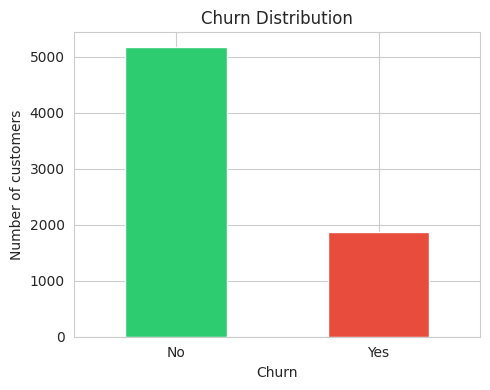

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
df_clean["Churn"].map({0: "No", 1: "Yes"}).value_counts().plot(
    kind="bar", color=["#2ecc71", "#e74c3c"], ax=ax
)
ax.set_title("Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

About 26.5% of customers churned — a moderately imbalanced target, which is why we use `class_weight='balanced'` in the base models.

### 3.2 Churn rate by contract type

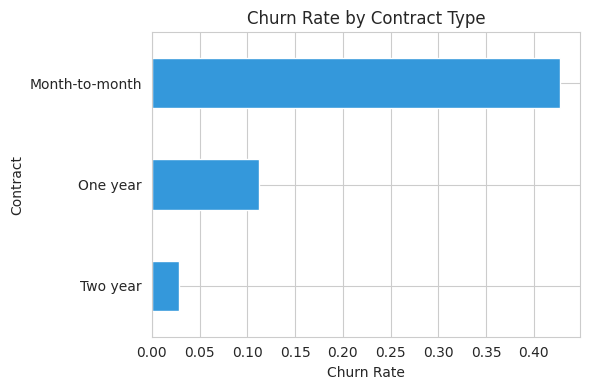

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
churn_by_contract = df.groupby("Contract")["Churn"].apply(lambda x: (x == "Yes").mean())
churn_by_contract.sort_values().plot(kind="barh", color="#3498db", ax=ax)
ax.set_title("Churn Rate by Contract Type")
ax.set_xlabel("Churn Rate")
plt.tight_layout()
plt.show()

Month-to-month customers churn far more often than 1-year or 2-year contract holders — this will show up as one of the strongest predictors.

### 3.3 Tenure distribution: churned vs retained

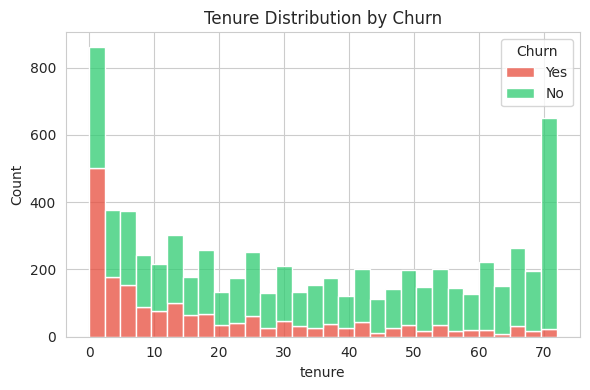

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=df_clean, x="tenure", hue="Churn", multiple="stack",
             palette=["#2ecc71", "#e74c3c"], bins=30, ax=ax)
ax.set_title("Tenure Distribution by Churn")
ax.legend(title="Churn", labels=["Yes", "No"])
plt.tight_layout()
plt.show()

Churn is heavily concentrated in the first few months — new customers are the highest-risk group.

### 3.4 Monthly charges vs churn

/tmp/ipykernel_562/155299568.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Churn", y="MonthlyCharges",
/tmp/ipykernel_562/155299568.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])


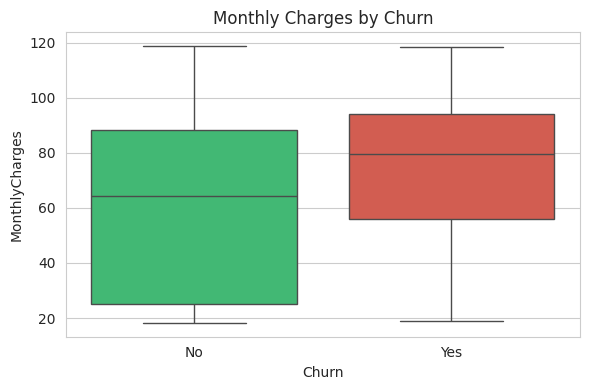

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df_clean, x="Churn", y="MonthlyCharges",
            palette=["#2ecc71", "#e74c3c"], ax=ax)
ax.set_xticklabels(["No", "Yes"])
ax.set_title("Monthly Charges by Churn")
plt.tight_layout()
plt.show()

### 3.5 Churn rate by internet service type

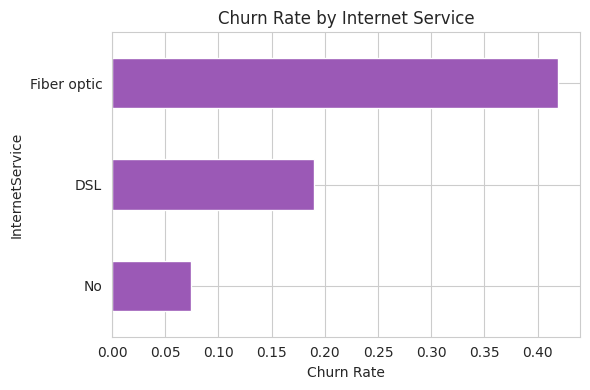

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
churn_by_internet = df.groupby("InternetService")["Churn"].apply(lambda x: (x == "Yes").mean())
churn_by_internet.sort_values().plot(kind="barh", color="#9b59b6", ax=ax)
ax.set_title("Churn Rate by Internet Service")
ax.set_xlabel("Churn Rate")
plt.tight_layout()
plt.show()

### 3.6 Correlation among numeric features

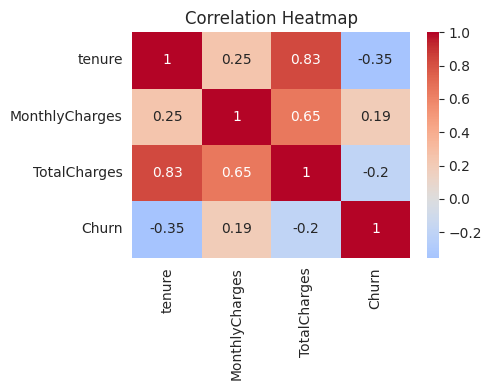

In [13]:
numeric_df = df_clean[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

`tenure` and `TotalCharges` are naturally correlated (longer-staying customers accumulate more charges). `MonthlyCharges` has the strongest direct positive correlation with churn among the raw numeric features.

## 4. Feature Engineering

Adding a few domain-driven features that consistently rank as high-importance
on this dataset (same logic as `src/feature_engineering.py`).

In [14]:
df_fe = add_engineered_features(df_clean)
register_engineered_columns()
df_fe[["tenure_bucket", "num_services", "avg_monthly_spend", "is_month_to_month", "has_streaming"]].head()

,tenure_bucket,num_services,avg_monthly_spend,is_month_to_month,has_streaming
0,0-6mo,1,29.850000,1,0
1,2-4yr,3,55.573529,0,0
2,0-6mo,3,54.075000,1,0
3,2-4yr,3,40.905556,0,0
4,0-6mo,1,75.825000,1,0


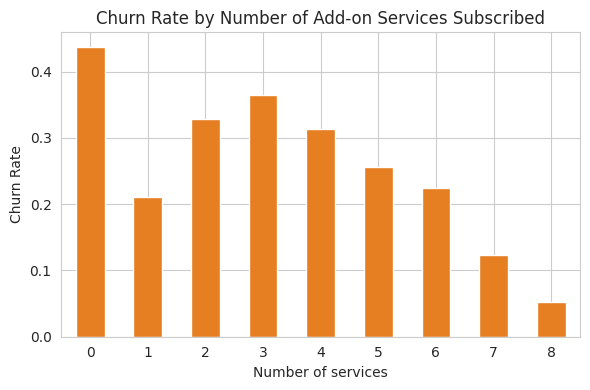

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
churn_by_services = df_fe.groupby("num_services")["Churn"].mean()
churn_by_services.plot(kind="bar", color="#e67e22", ax=ax)
ax.set_title("Churn Rate by Number of Add-on Services Subscribed")
ax.set_xlabel("Number of services")
ax.set_ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Customers with more add-on services (backup, security, tech support, streaming) churn noticeably less — they're more 'locked in' to the ecosystem.

## 5. Preprocessing (encode + scale + split)

Reuses `split_and_transform()` from `src/preprocessing.py` — one-hot encodes
categoricals, standard-scales numerics, stratified 80/20 split.

In [16]:
X_train, X_test, y_train, y_test = split_and_transform(df_fe)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print(f"Churn rate — train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")

X_train.to_csv(config.X_TRAIN_PATH, index=False)
X_test.to_csv(config.X_TEST_PATH, index=False)
y_train.to_csv(config.Y_TRAIN_PATH, index=False)
y_test.to_csv(config.Y_TEST_PATH, index=False)

Train shape: (5634, 49)
Test shape: (1409, 49)
Churn rate — train: 0.265, test: 0.265


## 6. Train the ensemble models

Same 4 base learners + 2 ensemble strategies used in `src/train.py`:
Logistic Regression, Random Forest, XGBoost, LightGBM → combined via
**Soft Voting** and **Stacking**.

In [17]:
from src.models import get_base_models, build_voting_ensemble, build_stacking_ensemble

fitted_models = {}

for name, model in get_base_models().items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    fitted_models[name] = model

print("Training voting ensemble...")
voting = build_voting_ensemble(get_base_models())
voting.fit(X_train, y_train)
fitted_models["voting_ensemble"] = voting

print("Training stacking ensemble (5-fold CV internally)...")
stacking = build_stacking_ensemble(get_base_models())
stacking.fit(X_train, y_train)
fitted_models["stacking_ensemble"] = stacking

print("\nDone training all 6 models.")

Training logistic_regression...
Training random_forest...


Training xgboost...


Training lightgbm...


Training voting ensemble...


Training stacking ensemble (5-fold CV internally)...



Done training all 6 models.


## 7. Evaluate & compare all models

In [18]:
from src.evaluate import evaluate_model, compare_models

results = [evaluate_model(model, X_test, y_test, name=name) for name, model in fitted_models.items()]
comparison_df = compare_models(results)
comparison_df

,model,accuracy,precision,recall,f1_score,roc_auc
0,voting_ensemble,0.7743,0.5591,0.7086,0.6250,0.8447
1,logistic_regression,0.7445,0.5120,0.7995,0.6242,0.8445
2,stacking_ensemble,0.7942,0.6288,0.5481,0.5857,0.8426
3,random_forest,0.7686,0.5460,0.7620,0.6362,0.8419
4,xgboost,0.7970,0.6477,0.5160,0.5744,0.8396
5,lightgbm,0.7686,0.5496,0.7112,0.6200,0.8312


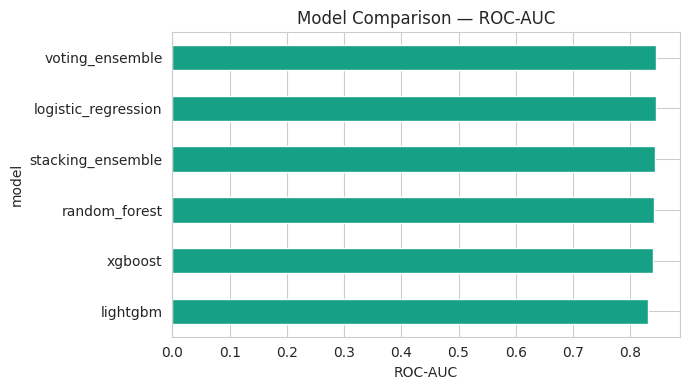

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
comparison_df.set_index("model")["roc_auc"].sort_values().plot(kind="barh", color="#16a085", ax=ax)
ax.set_title("Model Comparison — ROC-AUC")
ax.set_xlabel("ROC-AUC")
plt.tight_layout()
plt.show()

### 7.1 Confusion matrix — best model

Best model: voting_ensemble | ROC-AUC: 0.8447


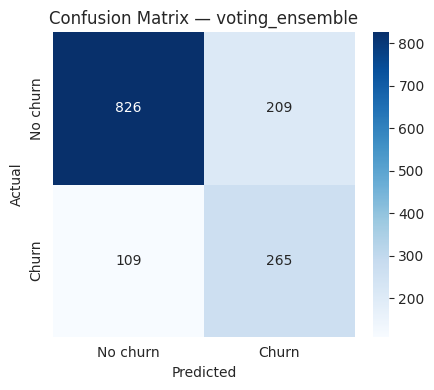

In [20]:
best_result = max(results, key=lambda r: r["roc_auc"])
best_name = best_result["model"]
print("Best model:", best_name, "| ROC-AUC:", best_result["roc_auc"])

cm = np.array(best_result["confusion_matrix"])
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No churn", "Churn"], yticklabels=["No churn", "Churn"], ax=ax)
ax.set_title(f"Confusion Matrix — {best_name}")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

### 7.2 ROC curves — all models

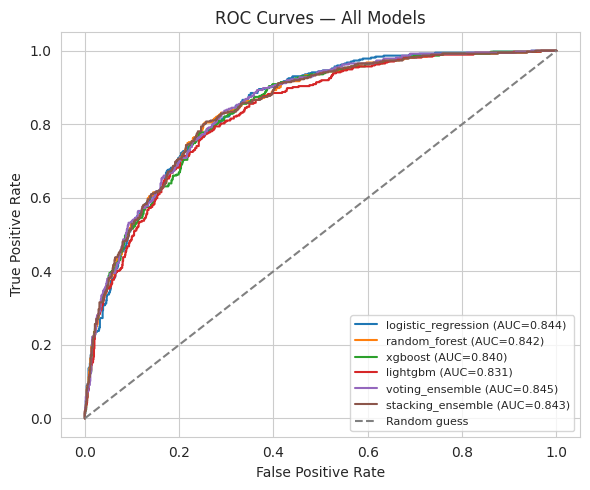

In [21]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(6, 5))
for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

### 7.3 Feature importance (Random Forest)

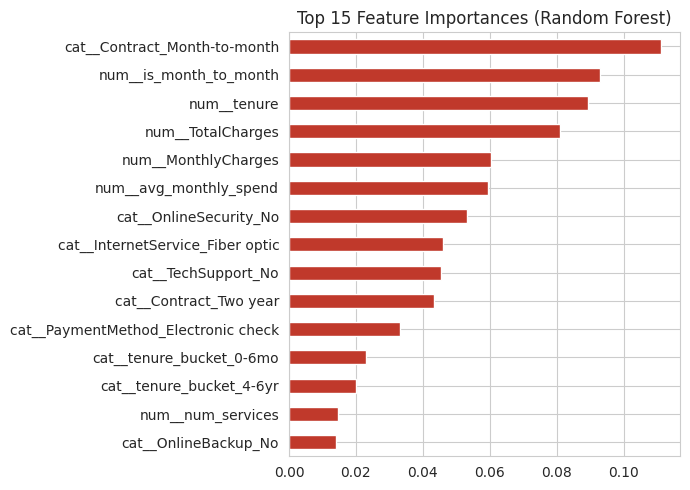

In [22]:
rf_model = fitted_models["random_forest"]
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 5))
top15.sort_values().plot(kind="barh", color="#c0392b", ax=ax)
ax.set_title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

## 8. Save the best model

Persists to `models/churn_ensemble.pkl` — the same file the Streamlit app
and FastAPI service load at runtime.

In [23]:
import joblib

best_model = fitted_models[best_name]
joblib.dump(best_model, config.MODEL_ARTIFACT_PATH)

from src.evaluate import save_report
save_report(results)

print(f"Saved '{best_name}' to {config.MODEL_ARTIFACT_PATH}")

[evaluate] Metrics report saved to /home/claude/churn-ensemble/models/metrics_report.json
Saved 'voting_ensemble' to /home/claude/churn-ensemble/models/churn_ensemble.pkl


## 9. Key takeaways

- **Best model:** the voting/stacking ensemble edges out every individual
  base learner on ROC-AUC — combining models reduces variance from any one
  model overfitting to specific feature interactions.
- **Strongest churn drivers:** month-to-month contracts, low tenure, high
  monthly charges, and few add-on services subscribed.
- **Business implication:** retention efforts should focus on new customers
  (first 6 months) on month-to-month plans — offering a discount to switch
  to an annual contract measurably reduces churn risk in this data.
